In [63]:
import scipy.interpolate as interp 
try:
    import cupy as xp
except (ImportError, ModuleNotFoundError) as e:
    import numpy as xp
from scipy.signal import windows 

from Triangle.Constants import *
from Triangle.FFTTools import *
from Triangle.Noise import *
from Triangle.Orbit import *
from Triangle.Data import *
from Triangle.TDI import *
from Triangle.GW import *
from Triangle.TDIFly import * 

import matplotlib
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['font.family'] = 'serif'
import matplotlib.pyplot as plt

In [64]:
import scipy.interpolate as interp 
try:
    import cupy as xp
    import cupyx.scipy.interpolate as xinterp
    print("has cupy")
except (ImportError, ModuleNotFoundError) as e:
    import numpy as xp
    import scipy.interpolate as xinterp  
    print("no cupy ") 

from Triangle.Constants import *
from Triangle.Orbit import *
from Triangle.TDI import *

import copy 


class TDIFly:
    
    X2_strings = {
        "12": [(1.0, []), (-1.0, ["13", "31"]), (-1.0, ["13", "31", "12", "21"]), (1.0, ["12", "21", "13", "31", "13", "31"])],
        "23": [],
        "31": [(-1.0, ["13"]), (1.0, ["12", "21", "13"]), (1.0, ["12", "21", "13", "31", "13"]), (-1.0, ["13", "31", "12", "21", "12", "21", "13"])],
        "21": [(1.0, ["12"]), (-1.0, ["13", "31", "12"]), (-1.0, ["13", "31", "12", "21", "12"]), (1.0, ["12", "21", "13", "31", "13", "31", "12"])],
        "32": [],
        "13": [(-1.0, []), (1.0, ["12", "21"]), (1.0, ["12", "21", "13", "31"]), (-1.0, ["13", "31", "12", "21", "12", "21"])],
    }

    def __init__(self, orbit, Pstring_list, tcb_times, Nsparse=512, use_gpu=False, drop_points=0):
        """
        Args:
            orbit: an Orbit object
            Pstring_list: list of P-strings, each specifiying a TDI channel 
            tcb_times: TCB times at which the TDI responses will be calculated, **NOTE** should be uniformly spaced for frequency-domain calculation
            Nsparse: number sparse time-domain samples, should be even to ensure 0-frequency is included 
        """
        self.orbit_object = orbit
        self.Nchannel = len(Pstring_list)
        self.tcb_times = tcb_times.copy()
        self.Ntime = len(tcb_times)
        self.dt = self.tcb_times[1] - self.tcb_times[0]
        self.Tobs = self.Ntime * self.dt
        self.Nsparse = int(Nsparse)
        self.drop_points = drop_points
        
        # xp functions 
        self.use_gpu = use_gpu
        if use_gpu:
            self.xp = xp
        else:
            self.xp = np
        self.COS = self.xp.cos 
        self.SIN = self.xp.sin 
        self.EXP = self.xp.exp 
        self.SINC = self.xp.sinc
        self.MATMUL = self.xp.matmul
        self.NX = self.xp.newaxis
        self.SUM = self.xp.sum 
        self.CONJ = self.xp.conjugate
        self.RE = self.xp.real

        # the orbit functions use numpy array as input
        # self.sparse_times = np.linspace(tcb_times[0], tcb_times[0]+self.Tobs, num=Nsparse, endpoint=False) # (Nsparse) ensure the same Tobs
        # Ensure the same Tobs. To avoid invalid values at the edge of td responses, the number of sparse time samples will be self.Nsparse + 1, and the last point will be removed in fd calculation
        self.sparse_times = np.linspace(tcb_times[0], tcb_times[0]+self.Tobs, num=Nsparse+1, endpoint=True) 
        self.sparse_dt = self.sparse_times[1] - self.sparse_times[0] 
        self.sparse_t0 = self.sparse_times[0]
        self.sparse_tf = self.sparse_times[-1]

        self.Ndelay_dict = []
        self.delay_factor_dict = [] 
        self.delay_dict = []
        self.delayed_dij_dict = []
        self.delayed_send_position_vector_dict = [] 
        self.delayed_recv_position_vector_dict = [] 
        for Pstring in Pstring_list: 
            # calculate sparsely sampled time series associated with orbit and time delays
            Ndelay_dict = {}  # each item is an integer
            for key in MOSA_labels:
                Ndelay_dict[key] = len(Pstring[key])

            delay_factor_dict = {}  # each item is a xp array of shape (Ndelay)
            for key in MOSA_labels:
                delay_factor_dict[key] = []
                for Idelay in range(Ndelay_dict[key]):
                    delay_factor_dict[key].append(Pstring[key][Idelay][0])
                delay_factor_dict[key] = self.xp.array(delay_factor_dict[key])

            delay_dict = {}  # each item is a numpy array of shape (Ndelay, Nsparse), not converted to xp array yet 
            for key in MOSA_labels:
                delay_dict[key] = []
                Pij = Pstring[key]
                for Idelay in range(Ndelay_dict[key]):
                    d_Idelay = np.zeros_like(self.sparse_times)
                    N_single_delay = len(Pij[Idelay][1])
                    for I_single_delay in range(N_single_delay): # nested delay is not necessary
                        if Pij[Idelay][1][I_single_delay][0] == "-":
                            d_Idelay += -orbit.LTTfunctions()[Pij[Idelay][1][I_single_delay][1:]](self.sparse_times)
                        else:
                            d_Idelay += orbit.LTTfunctions()[Pij[Idelay][1][I_single_delay]](self.sparse_times)
                    delay_dict[key].append(d_Idelay)

            delayed_dij_dict = {}  # dij delayed by d_Idelay, each item is a xp array of shape (Ndelay, Nsparse)
            for key in MOSA_labels:
                delayed_dij_dict[key] = []
                for Idelay in range(Ndelay_dict[key]):
                    delayed_dij_dict[key].append(orbit.LTTfunctions()[key](self.sparse_times - delay_dict[key][Idelay]))
                delayed_dij_dict[key] = self.xp.array(delayed_dij_dict[key])

            delayed_send_position_vector_dict = {}  # positions of sending SCs delayed by d_Idelay, each item (Ndelay, Nsparse, 3)
            for key in MOSA_labels:
                delayed_send_position_vector_dict[key] = []
                for Idelay in range(Ndelay_dict[key]):
                    delayed_send_position_vector_dict[key].append(orbit.Positionfunctions()[key[1]](self.sparse_times - delay_dict[key][Idelay]))
                delayed_send_position_vector_dict[key] = self.xp.array(delayed_send_position_vector_dict[key])

            delayed_recv_position_vector_dict = {}  # positions of receiving SCs delayed by d_Idelay, each item (Ndelay, Nsparse, 3)
            for key in MOSA_labels:
                delayed_recv_position_vector_dict[key] = []
                for Idelay in range(Ndelay_dict[key]):
                    delayed_recv_position_vector_dict[key].append(orbit.Positionfunctions()[key[0]](self.sparse_times - delay_dict[key][Idelay]))
                delayed_recv_position_vector_dict[key] = self.xp.array(delayed_recv_position_vector_dict[key])

            # convert delay dict to xp array at last since it is used in the calculation of other dicts
            for key in MOSA_labels:
                delay_dict[key] = self.xp.array(delay_dict[key])
                
            # collect all the TDI channels 
            self.Ndelay_dict.append(Ndelay_dict) # Nchannel elements 
            self.delay_factor_dict.append(delay_factor_dict)
            self.delay_dict.append(delay_dict)
            self.delayed_dij_dict.append(delayed_dij_dict)
            self.delayed_send_position_vector_dict.append(delayed_send_position_vector_dict)
            self.delayed_recv_position_vector_dict.append(delayed_recv_position_vector_dict)
                
        # calculate time series associated with orbit, irrelavent to Psting
        self.arm_vector_dict = assign_function_for_MOSAs(
            functions=orbit.ArmVectorfunctions(),
            proper_time=self.sparse_times,
        )  # each item is a xp array of shape (Nsparse, 3)
        for key in MOSA_labels:
            self.arm_vector_dict[key] = self.xp.array(self.arm_vector_dict[key])
            
        self.sc_position_vector_dict = {}  # positions of SCs, each item (Nsparse, 3)
        for key in SC_labels:
            self.sc_position_vector_dict[key] = self.xp.array(orbit.Positionfunctions()[key](self.sparse_times))
            
        self.dij_dict = {}  # delays, each item (Nsparse)
        for key in MOSA_labels: 
            self.dij_dict[key] = self.xp.array(orbit.LTTfunctions()[key](self.sparse_times))
            
        # convert sparse sample times to xp array and calculate its powers 
        self.sparse_times = self.xp.array(self.sparse_times, dtype=self.xp.float64)
        self.sparse_times2 = self.sparse_times ** 2 
        self.sparse_times3 = self.sparse_times ** 3 
        self.tcb_times = self.xp.array(self.tcb_times)
        
        # full frequencies 
        self.full_freq = self.xp.fft.rfftfreq(n=self.Ntime, d=self.dt)
        self.Nfrequency = len(self.full_freq)

    def vectorized_interp(self, x, xp0, xpf, dxp, xp, fp):
        """ 
        Args: 
            x: numpy or cupy array of shape (N) 
            xp0, xpf, dxp: initial, final values and sampling interval for a **uniformly sampled** xp series 
            xp: numpy or cupy array of shape (M) 
            fp: numpy or cupy array of shape (K, M)
        Returns:
            numpy or cupy array of shape (K, N)
        """
        # search the location of x in xp 
        # indices = self.xp.searchsorted(xp, x, side='right') - 1
        # indices = self.xp.floor((x - xp0) / dxp).astype(self.xp.int32)
        indices = ((x - xp0) / dxp).astype(self.xp.int32)
        indices = self.xp.clip(indices, 0, len(xp) - 2)
        
        # calculate weights for linear interpolation 
        x_left = xp[indices]
        x_right = xp[indices + 1]
        weights = (x - x_left) / (x_right - x_left)
        
        # get functon values at the left and right 
        fp_left = fp[:, indices]  
        fp_right = fp[:, indices + 1]  
        
        # calculate linear interpolation 
        result = fp_left + weights * (fp_right - fp_left)
        
        # deal with boundaries 
        below_mask = x < xp0 
        above_mask = x > xpf 
        result[:, below_mask] = fp[:, 0, self.NX]
        result[:, above_mask] = fp[:, -1, self.NX]
        return result
            

    
    
    
    
class TDIFlyGB(TDIFly):
    def __init__(self, orbit, Pstring_list, tcb_times, Nsparse=512, use_gpu=False, drop_points=0):
        super().__init__(orbit, Pstring_list, tcb_times, Nsparse, use_gpu, drop_points)

    def __call__(self, parameters, domain="time"):
        """
        Args:
            parameters: a dictionary storing the source parameters. Each parameter can be either a numpy array or a float number 
            domain: "time" or "frequency"
        Returns:
            the time / frequency series of TDI responses
        """
        A = self.xp.atleast_1d(parameters["A"]) # xp array of shape (Nevents)
        f0 = self.xp.atleast_1d(parameters["f0"])
        fdot0 = self.xp.atleast_1d(parameters["fdot0"])
        fddot0 = self.get_fddot(f=f0, fdot=fdot0)
        phase0 = self.xp.atleast_1d(parameters["phase0"])
        inclination = self.xp.atleast_1d(parameters["inclination"])
        longitude = self.xp.atleast_1d(parameters["longitude"])
        latitude = self.xp.atleast_1d(parameters["latitude"])
        psi = self.xp.atleast_1d(parameters["psi"])

        Nevents = len(A)
        
        # wave vectors 
        k = -self.xp.array([self.COS(latitude) * self.COS(longitude), self.COS(latitude) * self.SIN(longitude), self.SIN(latitude)]).T # (Nevents, 3)
        u = self.xp.array([self.SIN(longitude), -self.COS(longitude), self.xp.zeros(Nevents)]).T # (Nevents, 3)
        v = self.xp.array([-self.SIN(latitude) * self.COS(longitude), -self.SIN(latitude) * self.SIN(longitude), self.COS(latitude)]).T # (Nevents, 3)
        
        # arm projections 
        un12 = self.MATMUL(u, self.arm_vector_dict["12"].T) # (Nevents, Nsparse)
        un23 = self.MATMUL(u, self.arm_vector_dict["23"].T)
        un31 = self.MATMUL(u, self.arm_vector_dict["31"].T)
        vn12 = self.MATMUL(v, self.arm_vector_dict["12"].T) 
        vn23 = self.MATMUL(v, self.arm_vector_dict["23"].T)
        vn31 = self.MATMUL(v, self.arm_vector_dict["31"].T)
        
        # pattern functions in the SSB frame 
        xiplus12 = un12 ** 2 - vn12 ** 2 # (Nevents, Nsparse), xi_ij = xi_ji
        xiplus23 = un23 ** 2 - vn23 ** 2
        xiplus31 = un31 ** 2 - vn31 ** 2
        xicross12 = 2. * un12 * vn12
        xicross23 = 2. * un23 * vn23
        xicross31 = 2. * un31 * vn31 
        
        # pattern functions in the source frame 
        cos2psi = self.COS(2. * psi)[:, self.NX] # (Nevents, 1)
        sin2psi = self.SIN(2. * psi)[:, self.NX]
        zetaplus12 = cos2psi * xiplus12 + sin2psi * xicross12 # (Nevents, Nsparse)
        zetaplus23 = cos2psi * xiplus23 + sin2psi * xicross23
        zetaplus31 = cos2psi * xiplus31 + sin2psi * xicross31 
        zetacross12 = -sin2psi * xiplus12 + cos2psi * xicross12
        zetacross23 = -sin2psi * xiplus23 + cos2psi * xicross23
        zetacross31 = -sin2psi * xiplus31 + cos2psi * xicross31 
        zetaplus = {
                "12": zetaplus12,  # (Nevents, Nsparse)
                "23": zetaplus23, 
                "31": zetaplus31, 
                "21": zetaplus12, 
                "32": zetaplus23, 
                "13": zetaplus31 
            }
        zetacross = {
                "12": zetacross12, 
                "23": zetacross23, 
                "31": zetacross31, 
                "21": zetacross12, 
                "32": zetacross23, 
                "13": zetacross31 
            }
        
        # the knij terms 
        kn = dict() 
        for key in MOSA_labels: 
            kn[key] = self.MATMUL(k, self.arm_vector_dict[key].T) # (Nevents, Nsparse)
        
        # inclination 
        mu = self.COS(inclination)
        Aplus = ((1. + mu ** 2) / 2.)[:, self.NX] # (Nevents, 1)
        Across = -1.j * mu[:, self.NX] # (Nevents, 1)
        
        # phase and derivatives
        phi_GW = TWOPI * self.xp.outer(f0, self.sparse_times) + PI * self.xp.outer(fdot0, self.sparse_times2) + PI / 3. * self.xp.outer(fddot0, self.sparse_times3) + phase0[:, self.NX] # (Nevents, Nsparse)
        dphi_GW = TWOPI * self.xp.outer(fdot0, self.sparse_times) + PI * self.xp.outer(fddot0, self.sparse_times2) + TWOPI * f0[:, self.NX] # (Nevents, Nsparse)
        ddphi_GW = TWOPI * (self.xp.outer(fddot0, self.sparse_times) + fdot0[:, self.NX]) # (Nevents, Nsparse)
        dddphi_GW = TWOPI * fddot0[:, self.NX] # (Nevents, 1)
        
        # prepare for the heterodyned calculation 
        carrier_freq_idx = (dphi_GW[:, self.Nsparse//2] / TWOPI * self.Tobs).astype(self.xp.int32) # (Nevents) this is more accurate for high-frequency sources 
        # carrier_freq_idx = (f0 * self.Tobs).astype(self.xp.int32) # (Nevents) this is faster for low-frequency sources without loss of accuracy 
        carrier_phase = TWOPI / self.Tobs * carrier_freq_idx[:, self.NX] * self.sparse_times # (Nevents, Nsparse)
        self.start_idx = (carrier_freq_idx - self.Nsparse / 2).astype(self.xp.int32) # Nsparse should be even, (Nevents)
        
        # calculate TDI responses for multiple channels 
        tdi_responses = [] 
        for ichannel in range(self.Nchannel): 
            # combine the sparse TDI response 
            # sparse_response = self.xp.zeros((Nevents, self.Nsparse), dtype=self.xp.complex128)
            sparse_response = self.xp.zeros((Nevents, self.Nsparse+1), dtype=self.xp.complex128)
            for mosa in MOSA_labels: 
                if self.Ndelay_dict[ichannel][mosa] == 0: 
                    continue
                else: 
                    Denominator_term = 0.5 / (1. - kn[mosa]) # (Nevents, Nsparse)
                    Pattern_term = Aplus * zetaplus[mosa] + Across * zetacross[mosa] # (Nevents, Nsparse), complex 
                    # Phase_delay_term = self.xp.zeros((Nevents, self.Nsparse), dtype=self.xp.complex128)
                    Phase_delay_term = self.xp.zeros((Nevents, self.Nsparse+1), dtype=self.xp.complex128)
                    for Idelay in range(self.Ndelay_dict[ichannel][mosa]):
                        d_em = self.delay_dict[ichannel][mosa][Idelay] + self.delayed_dij_dict[ichannel][mosa][Idelay] + self.MATMUL(k, self.delayed_send_position_vector_dict[ichannel][mosa][Idelay].T) / C # (Nevents, Nsparse)
                        d_re = self.delay_dict[ichannel][mosa][Idelay] + self.MATMUL(k, self.delayed_recv_position_vector_dict[ichannel][mosa][Idelay].T) / C # (Nevents, Nsparse)
                        dphi_em = -dphi_GW * d_em + 0.5 * ddphi_GW * d_em ** 2 - 1. / 6. * dddphi_GW * d_em ** 3 
                        dphi_re = -dphi_GW * d_re + 0.5 * ddphi_GW * d_re ** 2 - 1. / 6. * dddphi_GW * d_re ** 3
                        Phase_delay_term += self.delay_factor_dict[ichannel][mosa][Idelay] * (self.EXP(1.j * dphi_em) - self.EXP(1.j * dphi_re))
                    sparse_response += Denominator_term * Pattern_term * Phase_delay_term

            # get the amplitude and phase of response 
            sparse_response_amp = self.xp.abs(sparse_response) # (Nevents, Nsparse)
            sparse_response_phase = self.xp.unwrap(self.xp.angle(sparse_response)) # unwrap to ensure continuity 
            
            if domain == "time":
                
                # combine the total sparse amplitude and phase 
                self.sparse_amp = 2. * A[:, self.NX] * sparse_response_amp # (Nevents, Nsparse)
                self.sparse_phase = sparse_response_phase + phi_GW # (Nevents, Nsparse)
                
                # calculate tdi variable at full sampling rate 
                full_amp = self.vectorized_interp(
                    x=self.tcb_times, 
                    xp0=self.sparse_t0, 
                    xpf=self.sparse_tf, 
                    dxp=self.sparse_dt, 
                    xp=self.sparse_times, 
                    fp=self.sparse_amp
                    ) # (Nevents, Ntime)
                full_phase = self.vectorized_interp(
                    x=self.tcb_times, 
                    xp0=self.sparse_t0, 
                    xpf=self.sparse_tf, 
                    dxp=self.sparse_dt, 
                    xp=self.sparse_times, 
                    fp=self.sparse_phase
                    ) # (Nevents, Ntime)
                
                # if Nevents == 1:
                #     res = self.RE(full_amp * self.EXP(1.j * full_phase))[0]
                #     res[:self.drop_points] = 0. 
                #     res[-self.drop_points:] = 0. 
                # else: 
                res = self.RE(full_amp * self.EXP(1.j * full_phase))
                res[:, :self.drop_points] = 0. 
                res[:, -self.drop_points:] = 0. 
                tdi_responses.append(res)
                
            elif domain == "frequency": 
                
                # combine the total sparse amplitude and phase 
                slow_amp = A[:, self.NX] * sparse_response_amp # (Nevents, Nsparse)
                slow_phase = sparse_response_phase + phi_GW # (Nevents, Nsparse)
                heterodyne_phase = slow_phase - carrier_phase # (Nevents, Nsparse)
                tmp = self.EXP(1.j * heterodyne_phase) * slow_amp # (Nevents, Nsparse)
                # tdi_f = self.xp.fft.fftshift(self.xp.fft.fft(tmp, axis=-1), axes=-1) * self.sparse_dt # (Nevents, Nsparse)
                tdi_f = self.xp.fft.fftshift(self.xp.fft.fft(tmp[:, :-1], axis=-1), axes=-1) * self.sparse_dt # (Nevents, Nsparse)
                
                
                # if Nevents == 1: 
                #     tdi_responses.append(tdi_f[0])
                # else: 
                tdi_responses.append(tdi_f)
            
            else: 
                raise ValueError("wrong domain.")
            
        return self.xp.array(tdi_responses) # (Nchannel, Nevents, Nsparse/Ntime)
    
    def fill_full_fftseries(self, data, start_idx):
        """ 
            data should be of shape (Nchannel, Nevents, Nfreq) 
            start_idx should be of shape (Nevents)
        """
        Nchannel = data.shape[0]
        Nevents = data.shape[1]
        template = self.xp.zeros((Nchannel, Nevents, self.Nfrequency), dtype=self.xp.complex128)
        template[
            self.xp.arange(Nchannel)[:, None, None], 
            self.xp.arange(Nevents)[None, :, None], 
            start_idx[None, :, None] + self.xp.arange(self.Nsparse)[None, None, :]
        ] = data 
        return template
    
    # def fill_fftseries(self, data, start_idx, StartBound, EndBound):
    #     """ 
    #         data should be of shape (Nchannel, Nevents, Nfreq) 
    #         start_idx should be of shape (Nevents)
    #         StartBound and EndBound are the starting idx and end idx of a slice within the full rfft frequency series 
    #     """
    #     Nchannel = data.shape[0]
    #     Nevents = data.shape[1]
    #     template_filled = self.xp.zeros((Nchannel, Nevents, EndBound + 1 - StartBound), dtype=self.xp.complex128)
    #     shifted_start_idx = start_idx - StartBound
    #     template_filled[
    #         self.xp.arange(Nchannel)[:, None, None], 
    #         self.xp.arange(Nevents)[None, :, None], 
    #         shifted_start_idx[None, :, None] + self.xp.arange(self.Nsparse)[None, None, :]
    #     ] = data 
    #     return template_filled
    
    def fill_fftseries(self, data, start_idx, StartBound, EndBound):
        """ 
            data should be of shape (Nchannel, Nevents, Nfreq) 
            start_idx should be of shape (Nevents)
            StartBound and EndBound are the starting idx and end idx of a slice within the full rfft frequency series 
        """
        Nchannel = data.shape[0]
        Nevents = data.shape[1]
        template_filled = self.xp.zeros((Nchannel, Nevents, EndBound + 1 - StartBound), dtype=self.xp.complex128)
        # adjusted_indices = self.xp.clip(start_idx, StartBound, EndBound) - StartBound
        # template_filled[tmp1, tmp2, adjusted_indices] = data 
        # template_filled[
        #     self.xp.arange(Nchannel)[:, None, None], 
        #     self.xp.arange(Nevents)[None, :, None], 
        #     start_idx[None, :, None] + self.xp.arange(self.Nsparse)[None, None, :] - StartBound
        # ] = data 
        template_filled[
            self.xp.arange(Nchannel)[:, None, None], 
            self.xp.arange(Nevents)[None, :, None], 
            self.xp.clip(start_idx[None, :, None] + self.xp.arange(self.Nsparse)[None, None, :], StartBound, EndBound) - StartBound
        ] = data 
        return template_filled

    def fill_fftseries_loop(self, data, start_idx, StartBound, EndBound):
        """ 
            data should be of shape (Nchannel, Nevents, Nfreq) 
            start_idx should be of shape (Nevents)
            StartBound and EndBound are the starting idx and end idx of a slice within the full rfft frequency series 
        """
        Nchannel = data.shape[0]
        Nevents = data.shape[1]
        template_filled = self.xp.zeros((Nchannel, Nevents, EndBound - StartBound + 1), dtype=self.xp.complex128)
        
        for ievent in range(Nevents):
            start_idx_event = start_idx[ievent]
            
            if start_idx_event >= StartBound:
                data_start_idx = 0  
                temp_start_idx = StartBound - start_idx_event
            else:
                data_start_idx = StartBound - start_idx_event
                temp_start_idx = 0

            data_end_idx = self.Nsparse - 1 if start_idx_event + self.Nsparse - 1 <= EndBound else EndBound - start_idx_event
            temp_end_idx = temp_start_idx + data_end_idx - data_start_idx 

            template_filled[:, ievent, temp_start_idx:temp_end_idx+1] = data[:, ievent, data_start_idx:data_end_idx+1]      
        return template_filled
    
    def PSD_OMS(self, f, soms=SOMS_nominal, L=L_nominal):
        u = TWOPI * f * L / C
        return (u * soms / L) ** 2 * (1.0 + (2e-3 / f) ** 4)
    
    def PSD_ACC(self, f, sacc=SACC_nominal, L=L_nominal):
        u = TWOPI * f * L / C
        return (sacc * L / u / C**2) ** 2 * (1.0 + (0.4e-3 / f) ** 2) * (1.0 + (f / 8e-3) ** 4)
    
    def PSD_X2(self, f, soms=SOMS_nominal, sacc=SACC_nominal, L=L_nominal):
        u = TWOPI * f * L / C
        Sa = self.PSD_ACC(f, sacc, L)
        So = self.PSD_OMS(f, soms, L)
        return 64.0 * (self.SIN(2. * u)) ** 2 * (self.SIN(u)) ** 2 * (So + (3.0 + self.COS(2. * u)) * Sa)

    def PSD_A2(self, f, soms=SOMS_nominal, sacc=SACC_nominal, L=L_nominal):
        u = TWOPI * f * L / C
        Sa = self.PSD_ACC(f, sacc, L)
        So = self.PSD_OMS(f, soms, L)
        PSD_A = 8.0 * So * (2.0 + self.COS(u)) * (self.SIN(u)) ** 2 + 16.0 * Sa * (3.0 + 2.0 * self.COS(u) + self.COS(2.0 * u)) * (self.SIN(u)) ** 2
        return 4.0 * (self.SIN(2. * u)) ** 2 * PSD_A
    
    def mismatch(self, h1, h2):
        """   
        Calculate the mismatches between data and multiple templates. The channels must be noise-orthogonal. 
        Args:
            h1: (Nchannel, Nfreq)
            h2: (Nchannel, Nevent, Nfreq)
        Returns: 
            mismatches (Nevent)
        """
        h2_T =  self.xp.transpose(h2, (1, 0, 2)) # (Nevent, Nchannel, Nfreq)
        h1h2_inner = self.RE(self.SUM(self.CONJ(h1) * h2_T, axis=(1, 2))) # (Nevent)
        h1_inner = self.SUM(self.xp.abs(h1) ** 2) # scalar 
        h2_inner = self.SUM(self.xp.abs(h2_T) ** 2, axis=(1, 2)) # (Nevent)
        return (1. - h1h2_inner / self.xp.sqrt(h1_inner * h2_inner)) # (Nevent)
    
    def SNR(self, h, f0, Tobs): 
        """   
        Calculate the SNRs of multiple events. The channel(s) must be A / E or A and E. 
        Args:
            h: (Nchannel, Nevent, Nfreq)
            f0: (Nevent)
            Tobs: scalar 
        Returns: 
            SNR (Nevent)
        """
        PSD = self.PSD_A2(f=f0) # (Nevent)
        return self.xp.sqrt(4. / Tobs / PSD * self.SUM(self.xp.abs(h) ** 2, axis=(0, 2))) # (Nevent)
    
    def Fstatistics(self, data, intrinsic_parameters, StartBound, EndBound, Tobs, S):
        """  
        calculate F-statistics for a batch of events within the same frequency bin 
        Args: 
            data: array of shape (Nchannel, Nfreqs), data in the frequency bin, the channels should be A / E or A and E 
            intrinsic_parameters: dictionary of parameters, each item is a numpy array. keys: "f0", "fdot0", "longitude", "latitude"
            StartBound, EndBound: int, start and end indices of the frequency bin in the whole rfftfreq array 
            Tobs: float 
            S: float, noise PSD in the frequnecy bin 
        Returns: 
            F-statistics of events 
        """
        Nevent = len(intrinsic_parameters["f0"])
        
        full_parameters1 = copy.deepcopy(intrinsic_parameters)
        full_parameters1["A"] = np.ones(Nevent) * 2. 
        full_parameters1["phase0"] = np.zeros(Nevent)
        full_parameters1["psi"] = np.zeros(Nevent)
        full_parameters1["inclination"] = np.ones(Nevent) * PI / 2. 
        temp1 = self.__call__(parameters=full_parameters1, domain="frequency") # (Nchannel=3, Nevent, Nsparse)
        temp1 = self.XYZtoAE(temp1)# (Nchannel=2, Nevent, Nsparse)
        temp_filled1 = self.fill_fftseries(
            data=temp1, 
            start_idx=self.start_idx, 
            StartBound=StartBound, 
            EndBound=EndBound
            ) # (Nchannel, Nevent, Nfreq)
        
        full_parameters2 = copy.deepcopy(full_parameters1)
        full_parameters2["psi"] = np.ones(Nevent) * PI / 4. 
        temp2 = self.__call__(parameters=full_parameters2, domain="frequency") # (Nchannel=3, Nevent, Nsparse)
        temp2 = self.XYZtoAE(temp2)# (Nchannel=2, Nevent, Nsparse)
        temp_filled2 = self.fill_fftseries(
            data=temp2, 
            start_idx=self.start_idx, 
            StartBound=StartBound, 
            EndBound=EndBound
            ) # (Nchannel, Nevent, Nfreq)

        X1 = self.xp.transpose(temp_filled1, axes=(1, 0, 2)) # (Nevent, Nchannel, Nfreq)
        X2 = 1.j * X1 # (Nevent, Nchannel, Nfreq)
        X3 = self.xp.transpose(temp_filled2, axes=(1, 0, 2)) # (Nevent, Nchannel, Nfreq)
        X4 = 1.j * X3 # (Nevent, Nchannel, Nfreq) 
        
        data_conj = self.CONJ(data)
        Nvector = self.xp.transpose(self.xp.array([
            self.SUM(self.RE(data_conj * X1), axis=(1, 2)), 
            self.SUM(self.RE(data_conj * X2), axis=(1, 2)), 
            self.SUM(self.RE(data_conj * X3), axis=(1, 2)), 
            self.SUM(self.RE(data_conj * X4), axis=(1, 2)), 
        ])) * 4. / Tobs / S # (Nevent, 4)
        
        M12 = self.SUM(self.RE(X1 * self.CONJ(X2)), axis=(1, 2))
        M13 = self.SUM(self.RE(X1 * self.CONJ(X3)), axis=(1, 2))
        M14 = self.SUM(self.RE(X1 * self.CONJ(X4)), axis=(1, 2))
        M23 = self.SUM(self.RE(X2 * self.CONJ(X3)), axis=(1, 2))
        M24 = self.SUM(self.RE(X2 * self.CONJ(X4)), axis=(1, 2))
        M34 = self.SUM(self.RE(X3 * self.CONJ(X4)), axis=(1, 2))
        Mmatrix = self.xp.transpose(self.xp.array([
            [self.SUM(self.xp.abs(X1) ** 2, axis=(1, 2)), M12, M13, M14], 
            [M12, self.SUM(self.xp.abs(X2) ** 2, axis=(1, 2)), M23, M24], 
            [M13, M23, self.SUM(self.xp.abs(X3) ** 2, axis=(1, 2)), M34], 
            [M14, M24, M34, self.SUM(self.xp.abs(X4) ** 2, axis=(1, 2))]
        ]), axes=(2, 0, 1)) * 4. / Tobs / S # (Nevent, 4, 4)
        
        invMmatrix = self.xp.linalg.inv(Mmatrix) # (Nevent, 4, 4)
        
        Nvector_col = Nvector[..., self.NX] # (Nevent, 4, 1)
        NM = self.MATMUL(invMmatrix, Nvector_col) # (Nevent, 4, 1)
        Nvector_row = Nvector[:, self.NX, :] # (Nevent, 1, 4)
        NMN = self.MATMUL(Nvector_row, NM) # (Nevent, 1, 1)
        
        res = 0.5 * NMN[:, 0, 0] # 0.5 * N^T M^{-1} N, (Nevent)
        if self.use_gpu:
            return res.get()
        else: 
            return res 
        
    def Likelihood(self, data, parameters, StartBound, EndBound, Tobs, S):
        """  
        calculate the log likelihoods -0.5 ( d - h | d - h) for a batch of events within the same frequency bin 
        Args: 
            data: array of shape (Nchannel, Nfreqs), data in the frequency bin, the channels should be A / E or A and E 
            parameters: dictionary of parameters, each item is a numpy array
            StartBound, EndBound: int, start and end indices of the frequency bin in the whole rfftfreq array 
            Tobs: float 
            S: float, noise PSD in the frequnecy bin 
        Returns: 
            loglikes of events 
        """
        temp = self.__call__(parameters=parameters, domain="frequency") # (Nchannel=3, Nevent, Nsparse)
        temp = self.XYZtoAE(temp) # (Nchannel=3, Nevent, Nsparse)
        temp_filled = self.fill_fftseries(
            data=temp, 
            start_idx=self.start_idx, 
            StartBound=StartBound, 
            EndBound=EndBound
            ) # (Nchannel, Nevent, Nfreq)
        temp_filled = self.xp.transpose(temp_filled, axes=(1, 0, 2)) # (Nevent, Nchannel, Nfreq)
        # print("shape of filled template:", temp_filled.shape) # TEST 

        residual = data - temp_filled # (Nevent, Nchannel, Nfreq)
        # print("shape of residual:", residual.shape) # TEST 
        
        res = -2. * self.SUM(self.xp.abs(residual) ** 2, axis=(1, 2)) / Tobs / S # (Nevent)
        if self.use_gpu:
            return res.get() 
        else: 
            return res 
        
    def XYZtoAE(self, template_channels): 
        A, E, _ = AETfromXYZ(template_channels[0], template_channels[1], template_channels[2]) # A / E of shape (Nevent, Nfreq)
        return self.xp.array([A, E]) # (Nchannel=2, Nevent, Nfreq)

    @staticmethod
    def get_fddot(f, fdot):
        return 11.0 / 3.0 * fdot ** 2 / f
    
    @staticmethod
    def get_chirpmass(f0, fdot0): 
        """   
        Args: 
            f0 in [Hz], fdot0 in [Hz/s]
        Returns: 
            Mc in [MSUN]
        """
        return (fdot0 / f0 ** (11./3.) * 5. * C ** 5 / 96. / PI ** (8./3.)) ** (3./5.) / G / MSUN 
    
    @staticmethod
    def get_D(f0, A, Mc): 
        """ 
        Args: 
            f0 in [Hz], A dimensionless, Mc in [MSUN]
        Returns: 
            D in [kpc]
        """
        return 2. * (G * Mc * MSUN) ** (5./3.) * (PI * f0) ** (2./3.) / C ** 4 / A / MPC * 1e3 

    @staticmethod    
    def ParamArr2Dict(parameters): 
        """ parameters: numpy array of shape (Nevents, Nparams) """
        param_dict = {
            'A': np.power(10, parameters[:, 0]),
            'f0': parameters[:, 1],
            'fdot0': parameters[:, 2],
            'phase0': parameters[:, 3],
            'inclination': np.arccos(parameters[:, 4]),
            'longitude': parameters[:, 5],
            'latitude': np.arcsin(parameters[:, 6]),
            'psi': parameters[:, 7]
            }
        return param_dict

    @staticmethod    
    def ParamDict2Arr(param_dict): 
        paramters = np.array([
            np.log10(param_dict["A"]), 
            param_dict["f0"], 
            param_dict["fdot0"], 
            param_dict["phase0"], 
            np.cos(param_dict["inclination"]), 
            param_dict["longitude"], 
            np.sin(param_dict["latitude"]), 
            param_dict["psi"], 
        ]).T 
        return paramters 
    

no cupy 


## Settings 

In [65]:
orbit = Orbit(OrbitDir="../OrbitData/MicroSateOrbitEclipticTCB")
Tobs = YEAR
dt = 10.0
tcb_times = np.arange(int(Tobs / dt)) * dt

## Initialize response models 

### TDI-on-the-fly

In [66]:
X2_strings = TDIFly.X2_strings
Y2_strings = TDIStringManipulation.TDIStringCyc(X2_strings)
Z2_strings = TDIStringManipulation.TDIStringCyc(Y2_strings)

gb_tdifly_generator = TDIFlyGB(
    orbit=orbit, 
    Pstring_list=[X2_strings, Y2_strings, Z2_strings], 
    tcb_times=tcb_times, 
    # Nsparse=1024, 
    Nsparse=512,
    # Nsparse=256,
    # drop_points=100, 
    use_gpu=False, 
)



### original polarization-based TDI response 

In [67]:
gb_waveform_generator = GB_Injection(use_gpu=False)
gb_response_generator = FastMichelsonTDIResponse(
    orbit=orbit, 
    tcb_times=tcb_times, 
    use_gpu=False, 
    drop_points=100, 
    # interp_method="linear", 
    interp_method="Akima", 
)

## Source population 

In [68]:
GB_catalogue = np.load("/Users/taijidatacenter/workspace/Triangle-GB/Examples/BrightGBParams.npy")
GB_parameters = dict(
    A=GB_catalogue[:, 0], 
    f0=GB_catalogue[:, 1], 
    fdot0=GB_catalogue[:, 2], 
    inclination=GB_catalogue[:, 5], 
    phase0=GB_catalogue[:, 4], 
    longitude=GB_catalogue[:, 6], 
    latitude=GB_catalogue[:, 7], 
    psi=GB_catalogue[:, 8], 
)

N_GB_total = GB_catalogue.shape[0]
N_GB_total

18984

## Compare one selected source 

In [69]:
test_GB_idx = int(np.random.uniform(0, N_GB_total))
test_GB_parameters = dict()
for k, v in GB_parameters.items():
    test_GB_parameters[k] = v[test_GB_idx]
test_GB_idx, test_GB_parameters

(18050,
 {'A': 2.2294149175286784e-23,
  'f0': 0.003073799841886283,
  'fdot0': 4.1111881244037874e-17,
  'inclination': 2.8402661126667947,
  'phase0': 0.7045222819980435,
  'longitude': 4.756369126067378,
  'latitude': 0.07567398274741767,
  'psi': 0.19580361751343286})

In [70]:
mich_aet_td = gb_response_generator(
    parameters=test_GB_parameters, 
    waveform_generator=gb_waveform_generator, 
    optimal_combination=True, 
    )

mich_a = xp.fft.rfft(mich_aet_td[0]) * dt 
mich_e = xp.fft.rfft(mich_aet_td[1]) * dt 
freqs = xp.fft.rfftfreq(n=mich_aet_td.shape[-1], d=dt)

cut_freq_range = 5e-5 
# cut_freq_range = 5e-6
cut_freq_idx = xp.where(xp.abs(freqs-test_GB_parameters["f0"])<cut_freq_range)[0]
freqs = freqs[cut_freq_idx]
mich_ae = xp.array([
    mich_a[cut_freq_idx], 
    mich_e[cut_freq_idx], 
])

mich_ae.shape # (Nchannel, Nfreq)

(2, 3156)

In [71]:
test_GB_parameters_vec = dict()
for k, v in test_GB_parameters.items():
    test_GB_parameters_vec[k] = v * np.ones(1)

fly_xyz = gb_tdifly_generator(
    parameters=test_GB_parameters_vec, 
    domain="frequency"
    )
fly_aet = AETfromXYZ(fly_xyz[0], fly_xyz[1], fly_xyz[2])
fly_ae_valid = xp.array([fly_aet[0], fly_aet[1]])


fly_ae = gb_tdifly_generator.fill_fftseries(
    data=fly_ae_valid, 
    start_idx=gb_tdifly_generator.start_idx, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1],
)

# fly_ae = gb_tdifly_generator.fill_fftseries_loop(
#     data=fly_ae_valid, 
#     start_idx=gb_tdifly_generator.start_idx, 
#     StartBound=cut_freq_idx[0], 
#     EndBound=cut_freq_idx[-1],
# )

fly_ae.shape # (Nchannel, Nevent, Nfreq)

(2, 1, 3156)

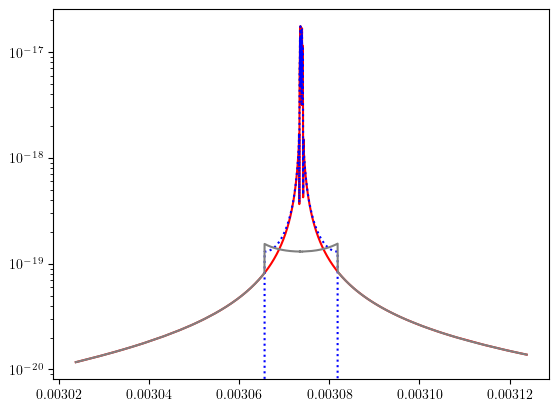

In [72]:
for ichannel, nchannel in enumerate(["A"]):
    plt.semilogy(freqs, np.abs(mich_ae[ichannel]), color="r")
    plt.semilogy(freqs, np.abs(fly_ae[ichannel][0]), linestyle=":", color="b")
    plt.semilogy(freqs, np.abs(fly_ae[ichannel][0] - mich_ae[ichannel]), linestyle="-", color="grey")

In [73]:
print("template SNR:", gb_tdifly_generator.SNR(fly_ae, test_GB_parameters["f0"], Tobs))
print("data SNR:", gb_tdifly_generator.SNR(mich_ae[:, xp.newaxis, :], test_GB_parameters["f0"], Tobs))
print("residual SNR:", gb_tdifly_generator.SNR(fly_ae - mich_ae[:, xp.newaxis,:], test_GB_parameters["f0"], Tobs))
print("mismatch:", gb_tdifly_generator.mismatch(h1=mich_ae, h2=fly_ae))
print("mismatch threshold:", 2. * 8. / gb_tdifly_generator.SNR(fly_ae, test_GB_parameters["f0"], Tobs) ** 2)

template SNR: [30.95308315]
data SNR: [30.94813865]
residual SNR: [2.14709898]
mismatch: [0.00240621]
mismatch threshold: [0.01669983]


## Test F-stat and likelihood 

In [74]:
intrinsic_parameters={
    "f0": test_GB_parameters["f0"], 
    "fdot0": test_GB_parameters["fdot0"], 
    "longitude": test_GB_parameters["longitude"], 
    "latitude": test_GB_parameters["latitude"]
}
for k, v in intrinsic_parameters.items():
    intrinsic_parameters[k] = np.atleast_1d(v)

gb_tdifly_generator.Fstatistics(
    data=mich_ae, 
    intrinsic_parameters=intrinsic_parameters, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"])
)

array([476.5921069])

In [75]:
gb_tdifly_generator.Likelihood(
    data=mich_ae, 
    parameters=test_GB_parameters, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"])
)

array([-2.30501702])

In [76]:
Ntest = 101
test_scale = 1e-8
test_params = test_GB_parameters["f0"] + np.linspace(-test_scale, test_scale, Ntest)
test_all_params = dict()
test_int_params = dict() 
for k, v in test_GB_parameters.items():
    test_all_params[k] = np.ones(Ntest) * v 
    if k in ["f0", "fdot0", "longitude", "latitude"]: 
        test_int_params[k] = np.ones(Ntest) * v 
    if k == "f0": 
        test_all_params[k] = test_params 
        test_int_params[k] = test_params

FLL = gb_tdifly_generator.Fstatistics(
    data=mich_ae, 
    intrinsic_parameters=test_int_params, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"])
)

LL = gb_tdifly_generator.Likelihood(
    data=mich_ae, 
    parameters=test_all_params, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"])
)

FLL.shape, LL.shape 

((101,), (101,))

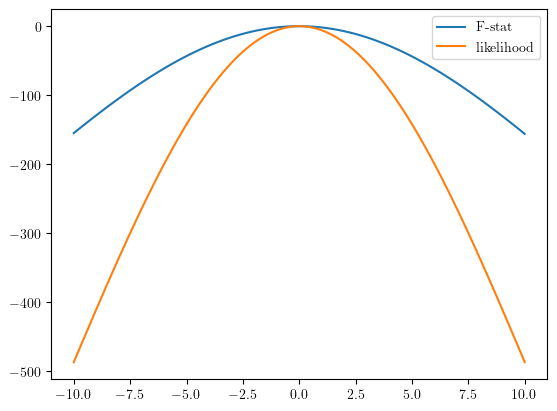

In [77]:
plt.plot((test_params - test_GB_parameters["f0"])*1e9, (FLL - np.max(FLL)), label="F-stat")
plt.plot((test_params - test_GB_parameters["f0"])*1e9, LL - np.max(LL), label="likelihood")
plt.legend()

In [78]:
Ntest = 101
test_scale = 1e-16
test_params = test_GB_parameters["fdot0"] + np.linspace(-test_scale, test_scale, Ntest)
test_all_params = dict()
test_int_params = dict() 
for k, v in test_GB_parameters.items():
    test_all_params[k] = np.ones(Ntest) * v 
    if k in ["f0", "fdot0", "longitude", "latitude"]: 
        test_int_params[k] = np.ones(Ntest) * v 
    if k == "fdot0": 
        test_all_params[k] = test_params 
        test_int_params[k] = test_params

FLL = gb_tdifly_generator.Fstatistics(
    data=mich_ae, 
    intrinsic_parameters=test_int_params, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"])
)

LL = gb_tdifly_generator.Likelihood(
    data=mich_ae, 
    parameters=test_all_params, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"])
)

FLL.shape, LL.shape 

((101,), (101,))

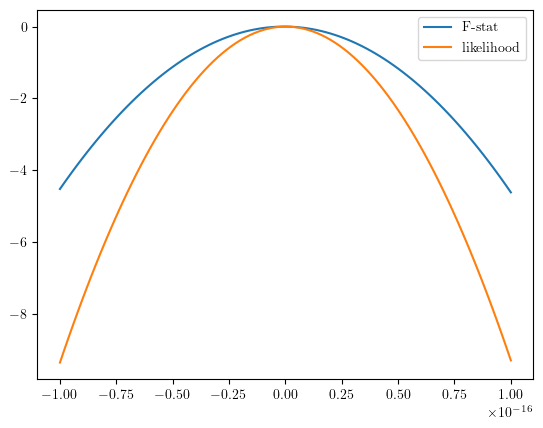

In [79]:
plt.plot((test_params - test_GB_parameters["fdot0"]), (FLL - np.max(FLL)), label="F-stat")
plt.plot((test_params - test_GB_parameters["fdot0"]), LL - np.max(LL), label="likelihood")
plt.legend()

In [80]:
Ntest = 101
test_scale = 1e-1
test_params = test_GB_parameters["longitude"] + np.linspace(-test_scale, test_scale, Ntest)
test_all_params = dict()
test_int_params = dict() 
for k, v in test_GB_parameters.items():
    test_all_params[k] = np.ones(Ntest) * v 
    if k in ["f0", "fdot0", "longitude", "latitude"]: 
        test_int_params[k] = np.ones(Ntest) * v 
    if k == "longitude": 
        test_all_params[k] = test_params 
        test_int_params[k] = test_params

FLL = gb_tdifly_generator.Fstatistics(
    data=mich_ae, 
    intrinsic_parameters=test_int_params, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"])
)

LL = gb_tdifly_generator.Likelihood(
    data=mich_ae, 
    parameters=test_all_params, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"])
)

FLL.shape, LL.shape 

((101,), (101,))

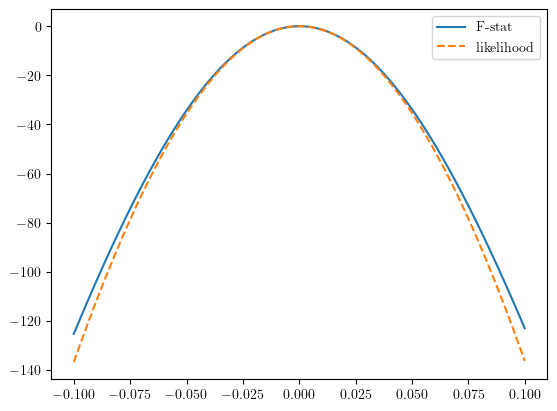

In [81]:
plt.plot((test_params - test_GB_parameters["longitude"]), (FLL - np.max(FLL)), label="F-stat")
plt.plot((test_params - test_GB_parameters["longitude"]), LL - np.max(LL), label="likelihood", linestyle="--")
plt.legend()

In [82]:
Ntest = 101
test_scale = 1e-1
test_params = test_GB_parameters["latitude"] + np.linspace(-test_scale, test_scale, Ntest)
test_all_params = dict()
test_int_params = dict() 
for k, v in test_GB_parameters.items():
    test_all_params[k] = np.ones(Ntest) * v 
    if k in ["f0", "fdot0", "longitude", "latitude"]: 
        test_int_params[k] = np.ones(Ntest) * v 
    if k == "latitude": 
        test_all_params[k] = test_params 
        test_int_params[k] = test_params

FLL = gb_tdifly_generator.Fstatistics(
    data=mich_ae, 
    intrinsic_parameters=test_int_params, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"])
)

LL = gb_tdifly_generator.Likelihood(
    data=mich_ae, 
    parameters=test_all_params, 
    StartBound=cut_freq_idx[0], 
    EndBound=cut_freq_idx[-1], 
    Tobs=Tobs, 
    S=gb_tdifly_generator.PSD_A2(f=test_GB_parameters["f0"])
)

FLL.shape, LL.shape 

((101,), (101,))

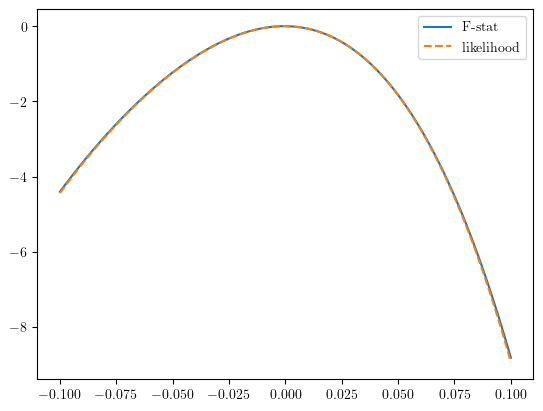

In [83]:
plt.plot((test_params - test_GB_parameters["latitude"]), (FLL - np.max(FLL)), label="F-stat")
plt.plot((test_params - test_GB_parameters["latitude"]), LL - np.max(LL), label="likelihood", linestyle="--")
plt.legend()